<a href="https://colab.research.google.com/github/jeevanshibatra27-create/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("customer_support_text_classification.csv")

In [18]:
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [19]:
df.shape

(1500, 6)

In [20]:
df.columns

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

In [21]:
print("Number of records:", len(df))

Number of records: 1500


In [22]:
print(df['sentiment_label'].unique())

['neutral' 'positive' 'negative']


In [23]:
print(df['sentiment_label'].value_counts())

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


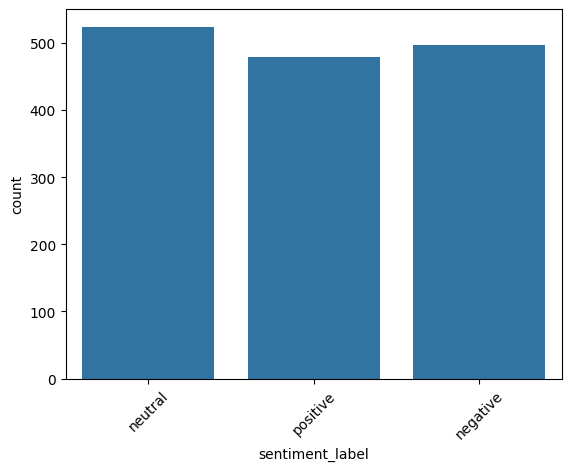

In [24]:
sns.countplot(x=df['sentiment_label'])
plt.xticks(rotation=45)
plt.show()

In [25]:
print(df['customer_message'].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


In [26]:
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))

print("Average text length:", df['text_length'].mean())

Average text length: 12.722666666666667


In [27]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [28]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [29]:
stop_words = set(stopwords.words('english'))

In [30]:
def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    text = " ".join(tokens)

    return text

In [32]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [33]:
df['clean_text'] = df['customer_message'].apply(preprocess_text)

In [34]:
df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['sentiment_label']

In [37]:
print(X.shape)

(1500, 146)


Text data cannot be directly understood by machine learning models because models work with numbers.
Therefore, text must be converted into numerical vectors using techniques like TF-IDF, Bag of Words, or embeddings.
TF-IDF helps represent important words based on their frequency and uniqueness in the dataset.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [41]:
y_pred = model.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [43]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [45]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.preprocessing import LabelEncoder

In [46]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [47]:
X_seq = pad_sequences(sequences, maxlen=100)

In [48]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df['sentiment_label'])

In [49]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [50]:
lstm_model = Sequential([

    Embedding(input_dim=5000, output_dim=64, input_length=100),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(len(np.unique(y_encoded)), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [51]:
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [52]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.6271 - loss: 1.0132 - val_accuracy: 0.5292 - val_loss: 0.8261
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.9271 - loss: 0.4151 - val_accuracy: 1.0000 - val_loss: 0.1142
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 1.0000 - loss: 0.0389 - val_accuracy: 1.0000 - val_loss: 0.0091
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0014


In [53]:
loss, accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)

print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0014
Test Accuracy: 1.0
